## Data on Happiness from [Our World in Data](https://ourworldindata.org/happiness-and-life-satisfaction)

Our World in Data kindly provides code to fetch their data. You can easily get any of their data by clicking download in the bottom right of their graphs > Data > scroll down to Python instructions.

### Data sources

- [Wellbeing Research Centre (2025)](https://worldhappiness.report/ed/2025/)
- [Eurostat, OECD, and World Bank (2025)](https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.KD)
- With major processing by [Our World in Data](https://ourworldindata.org/)

## Step 0: Where our work goes

Colab gives every notebook its own small filesystem, separate from your Google
Drive. That is where we will put the figures we make today. Click the folder
icon on the left after you save one and you will see it appear.

## Step 1: Get set up

In [ ]:
# Import packages
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling, set once here so every figure below inherits it.
# The box around a chart is useless ink, so I like to drop the
# top and right edges and keep the two axes we actually read values from
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# A folder for the figures we save: 
# - Path() names the folder
# - mkdir() creates the folder
# exist_ok=True means "don't complain if the folder already exists"
output = Path("output")
output.mkdir(exist_ok=True)

print("saving figures to:", output.resolve())

In [ ]:
# Our World in Data lets you fetch any of their datasets straight from a URL
url = ("https://ourworldindata.org/grapher/gdp-vs-happiness.csv"
       "?v=1&csvType=full&useColumnShortNames=true")

raw = pd.read_csv(url, storage_options={'User-Agent': 'ECON2041'})

raw.head()

## Step 2: Cut the data down to what we want

The file has every country and every year. We want one year, countries only,
and no missing values.

In [ ]:
YEAR = 2024

# Keep countries only. owid_region is filled in for countries and empty for
# aggregates like "World" or "High-income countries".
countries = raw['owid_region'].notna()

happy = raw[countries & (raw['year'] == YEAR)].copy()

# Drop countries missing either variable, then give the columns short names
happy = happy.dropna(subset=['cantril_ladder_score', 'ny_gdp_pcap_pp_kd'])
happy = happy.rename(columns={
    'entity': 'Entity', 'year': 'Year',
    'cantril_ladder_score': 'Happiness', 'ny_gdp_pcap_pp_kd': 'GDP_pc',
})

happy[['Entity', 'Year', 'Happiness', 'GDP_pc']].head()

## Step 3: Get to know the data

In [5]:
# Peek at the first rows
happy.head()

,Entity,Code,Year,cantril_ladder_score,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2023,1.721,1992.4244,Asia
1,Albania,ALB,2023,5.304,18244.2930,Europe
2,Algeria,DZA,2023,5.364,15159.3240,Africa
3,Argentina,ARG,2023,6.188,27104.9800,South America
4,Armenia,ARM,2023,5.455,19230.1900,Asia


In [ ]:
# Peek at the last rows
happy.tail(10)

,Entity,Code,Year,cantril_ladder_score,ny_gdp_pcap_pp_kd,owid_region
128,Uganda,UGA,2023,4.372,2791.0557,Africa
129,Ukraine,UKR,2023,4.873,15885.2260,Europe
130,United Arab Emirates,ARE,2023,6.733,68577.5400,Asia
131,United Kingdom,GBR,2023,6.749,54542.0160,Europe
132,United States,USA,2023,6.725,74577.5100,North America
133,Uruguay,URY,2023,6.611,31019.3100,South America
134,Uzbekistan,UZB,2023,6.195,10007.6860,Asia
135,Vietnam,VNM,2023,6.043,13491.8800,Asia
136,Zambia,ZMB,2023,3.502,3673.4841,Africa
137,Zimbabwe,ZWE,2023,3.341,3442.2512,Africa


### Sorted from least to most happy

In [ ]:
# Sorted from least to most happy. Any guesses which countries are down here?
happy.sort_values(
    by='Happiness',
    ascending=True
).head(10)[['Entity', 'Happiness', 'GDP_pc']]

### How many countries, which year?

In [ ]:
# How many countries, and which year?
print("rows, columns:", happy.shape)
print("year:", happy['Year'].unique())
print("countries:", happy['Entity'].nunique())

In [ ]:
# Count how many times each "entity" appears
entity_counts = happy.groupby("Entity")["Year"].nunique()
print(entity_counts)

# Check if panel or cross-section
if entity_counts.max() > 1:
    print("This is panel (longitudinal) data")
else:
    print("This is cross-sectional data")

Entity
Afghanistan    1
Albania        1
Algeria        1
Argentina      1
Armenia        1
              ..
Uruguay        1
Uzbekistan     1
Vietnam        1
Zambia         1
Zimbabwe       1
Name: Year, Length: 138, dtype: int64
This is cross-sectional data


### Summarize the middle

In [ ]:
# Simple numeric summary
happy.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,138.0,2023.00,0.00,2023.00,2023.00,2023.00,2023.00,2023.00
Happiness,138.0,5.55,1.15,1.72,4.80,5.80,6.40,7.74
GDP_pc,138.0,27484.10,26348.22,1455.84,6472.56,18468.34,43906.08,132846.58


In [ ]:
# We don't really need the summary statistics for Year
happy[['Happiness', 'GDP_pc']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Happiness,138.0,5.55,1.15,1.72,4.80,5.80,6.40,7.74
GDP_pc,138.0,27484.10,26348.22,1455.84,6472.56,18468.34,43906.08,132846.58


### Anything missing?

In [ ]:
# Missing values?
na_counts = happy.isna().sum().sort_values(ascending=False)
print("\nmissing values by column:")
print(na_counts[na_counts > 0])


missing values by column:
Series([], dtype: int64)


## Step 4: Examine empirical pdfs

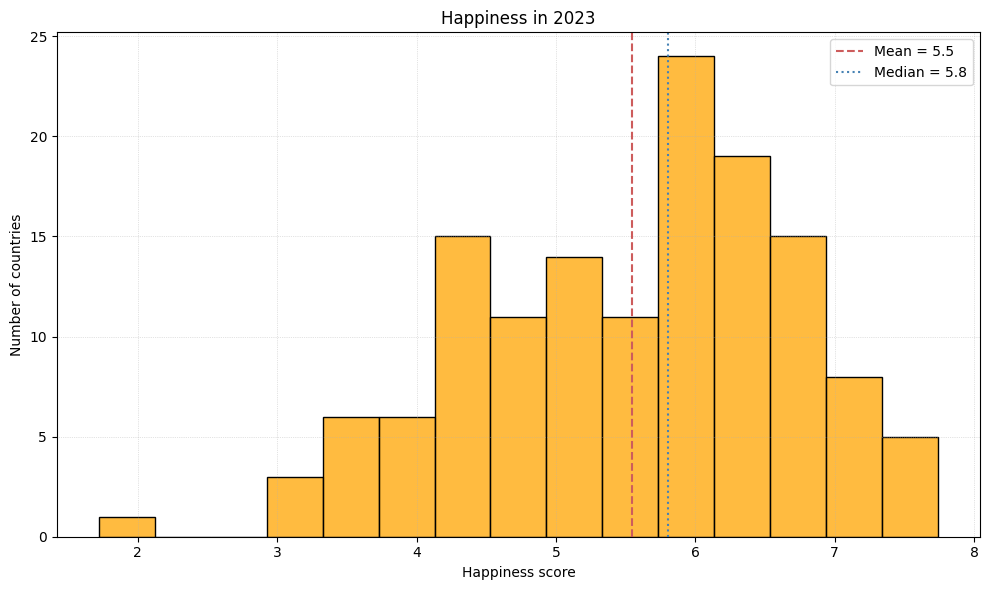

In [ ]:
# Plot a histogram of happiness
plt.figure(figsize=(10, 6))

sns.histplot(happy['Happiness'], bins=15, color="orange", edgecolor = "black", kde=False)

# compute stats
mean_happiness = happy['Happiness'].mean()
median_happiness = happy['Happiness'].median()

# add lines
plt.axvline(mean_happiness, color="indianred", linestyle="--", linewidth=1.5, label=f"Mean = {mean_happiness:,.1f}")
plt.axvline(median_happiness, color="steelblue", linestyle=":", linewidth=1.5, label=f"Median = {median_happiness:,.1f}")

plt.title(f'Happiness in {YEAR}')
plt.xlabel('Happiness score')
plt.ylabel('Number of countries')
plt.legend()
plt.tight_layout()
plt.savefig(output / "happiness_histogram.png", dpi=300, bbox_inches='tight')  # Save the figure in 'output' folder
plt.show()

### The same picture for GDP

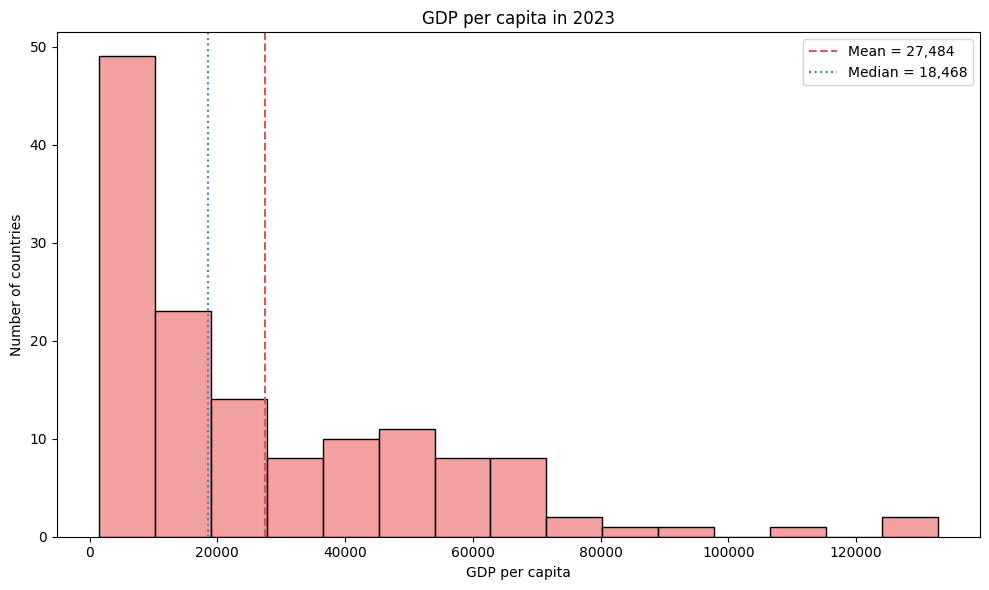

In [9]:
# Plot a histogram of GDP
plt.figure(figsize=(10, 6))
sns.histplot(happy['GDP_pc'], bins=15, color="lightcoral", edgecolor = "black", kde=False)

# compute stats
mean_gdp = happy['GDP_pc'].mean()
median_gdp = happy['GDP_pc'].median()

# add lines
plt.axvline(mean_gdp, color="indianred", linestyle="--", linewidth=1.5, label=f"Mean = {mean_gdp:,.0f}")
plt.axvline(median_gdp, color="steelblue", linestyle=":", linewidth=1.5, label=f"Median = {median_gdp:,.0f}")

plt.title(f'GDP per capita in {YEAR}')
plt.xlabel('GDP per capita')
plt.ylabel('Number of countries')
plt.legend()
plt.tight_layout()
plt.savefig(output / "gdp_histogram.png", dpi=300, bbox_inches='tight')  # Save the figure in 'output' folder
plt.show()

## Step 5: Look at the conditional distribution of happiness, given GDP

Let's see what $\mathbb{E}[ \text{Happiness} \: | \: \text{GDP per capita}]$ looks like!

In [ ]:
# The median GDP: half the countries sit above it, half below
median_gdp = happy['GDP_pc'].median()
median_gdp

### Booleans, doing real work

Ask a yes-or-no question of a whole column and you get one answer per country.

In [ ]:
# Ask the question of every country at once
happy['GDP_pc'] > median_gdp

### The boolean mask

That column of `True`/`False` is a **boolean mask**.

Counting with it: `True` is 1 and `False` is 0, so the sum counts the yeses and the mean is the share.

In [ ]:
mask = happy['GDP_pc'] > median_gdp

print("countries above median GDP:", mask.sum())
print("share above median GDP:", mask.mean())

### Splitting with the mask

A mask can also **split** the data.

In [ ]:
# Keep it as a column so we can group by it later
happy['high_GDP'] = happy['GDP_pc'] > median_gdp

# A readable label for plotting
happy['GDP_group'] = happy['high_GDP'].map({True: 'High GDP', False: 'Low GDP'})

happy[['Entity', 'GDP_pc', 'high_GDP', 'GDP_group']].head()

### The conditional distribution in one line

Describe happiness *within* each group.

This is what $\mathbb{E}[ \text{Happiness} \: | \: \text{GDP per capita}]$ means in practice.

In [ ]:
happy.groupby('GDP_group')['Happiness'].describe()

### Are the two distributions independent?

If happiness and GDP were independent, conditioning on GDP would leave the distribution of happiness unchanged.

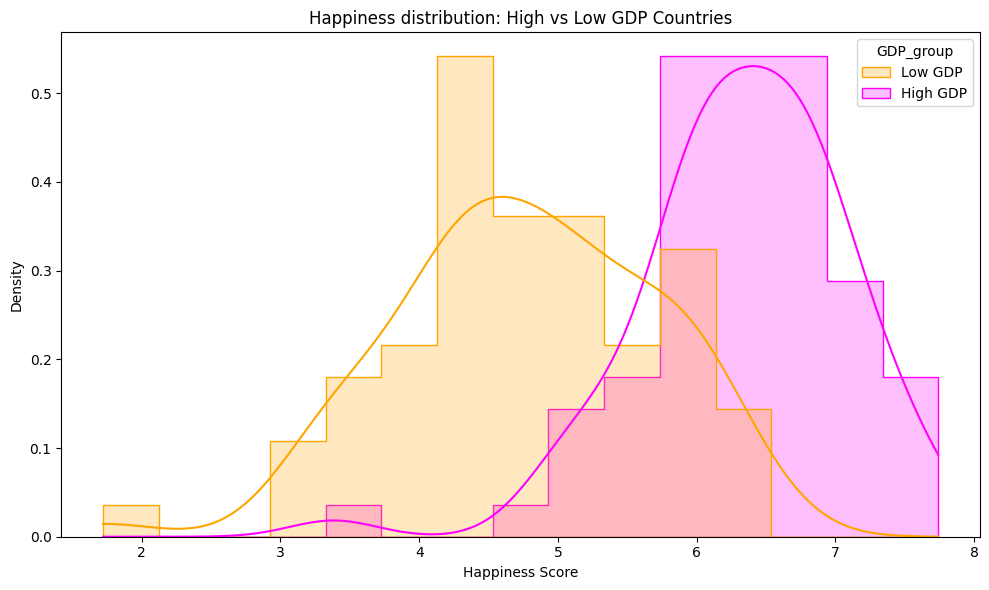

In [11]:
# Plot the conditional distribution
plt.figure(figsize=(10,6))
sns.histplot(data=happy, x='Happiness', hue='GDP_group', bins=15, element="step" , kde=True, stat='density', common_norm=False, palette={'High GDP': 'magenta', 'Low GDP': 'orange'})
plt.title('Happiness distribution: High vs Low GDP Countries')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(output / "happiness_by_gdpgroup.png", dpi=300, bbox_inches='tight') # Save the figure in 'output' folder
plt.show()

## Step 6: Examine the joint distribution

In [ ]:
# The joint distribution: every dot is one country
plt.figure(figsize=(10,6))
sns.scatterplot(data=happy, x='GDP_pc', y='Happiness', s=100, alpha=0.7, color='steelblue')
plt.title(f'GDP per capita vs Happiness score ({YEAR})')
plt.xlabel('GDP per capita (PPP, 2021 international dollars)')
plt.ylabel('Happiness score')
plt.tight_layout()
plt.show()

### The same cloud, colored by GDP group

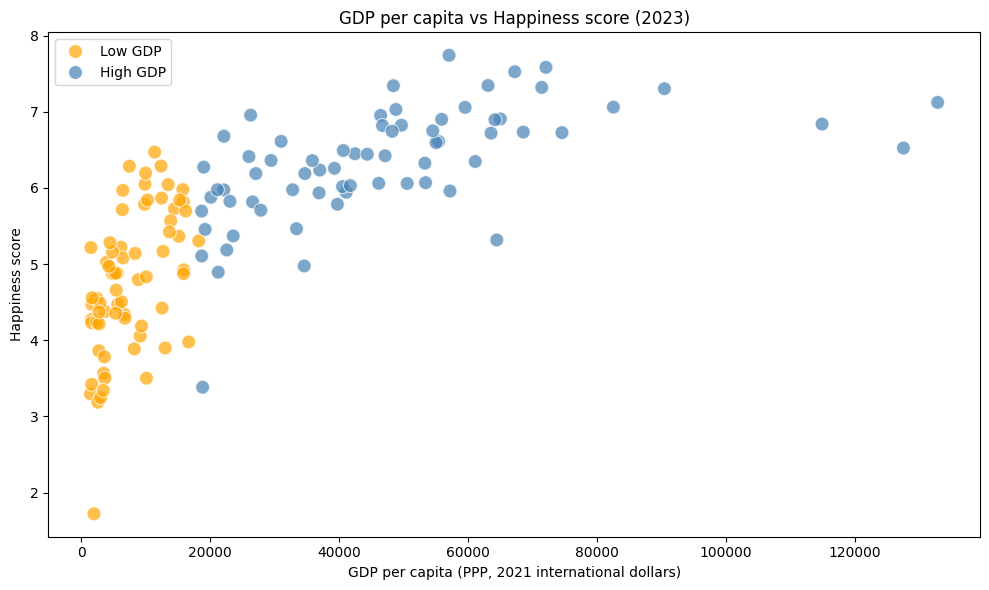

In [13]:
# The same cloud, colored by GDP group
plt.figure(figsize=(10,6))
sns.scatterplot(data=happy, x='GDP_pc', y='Happiness', s = 100, alpha=0.7, hue='GDP_group', palette={'High GDP': 'steelblue', 'Low GDP': 'orange'})
plt.title(f'GDP per capita vs Happiness score ({YEAR})')
plt.xlabel('GDP per capita (PPP, 2021 international dollars)')
plt.ylabel('Happiness score')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(output / "happiness_vs_gdp.png", dpi=300) # Save the figure in 'output' folder
plt.show()

## Step 7: Was the median the right place to split?

We split at the median because it was easy, not because it was right. Nothing
made us do that. We could have compared the top third with the bottom third,
or the richest tenth with the poorest tenth.

Each choice gives a different answer. Let's find out how different.

### Four rules for splitting

In [ ]:
def split_by(share):
    """Label the top and bottom `share` of countries by GDP per capita.

    share=0.5 splits everyone in two at the median. Smaller shares compare
    the extremes and throw the middle away.
    """
    low_cut = happy['GDP_pc'].quantile(share)
    high_cut = happy['GDP_pc'].quantile(1 - share)

    group = pd.Series('Middle (dropped)', index=happy.index)
    group[happy['GDP_pc'] <= low_cut] = 'Low GDP'
    group[happy['GDP_pc'] >= high_cut] = 'High GDP'
    return group


SPLITS = {
    'Richer half vs poorer half': 0.50,
    'Top third vs bottom third': 1 / 3,
    'Top quarter vs bottom quarter': 0.25,
    'Top tenth vs bottom tenth': 0.10,
}

### The numbers

For each rule: how many countries in each group, the mean happiness of each, and the gap.

In [ ]:
rows = []
for name, share in SPLITS.items():
    group = split_by(share)
    high = happy.loc[group == 'High GDP', 'Happiness']
    low = happy.loc[group == 'Low GDP', 'Happiness']

    # how precisely we know the gap, given how few countries are left
    se = np.sqrt(high.var(ddof=1) / len(high) + low.var(ddof=1) / len(low))

    rows.append({
        'rule': name,
        'n high': len(high),
        'n low': len(low),
        'mean high': high.mean(),
        'mean low': low.mean(),
        'gap': high.mean() - low.mean(),
        'std error of gap': se,
    })

pd.DataFrame(rows).set_index('rule').round(2)

### The same four choices as pictures

More extreme comparison: bigger gap, fewer countries, less certainty.

In [ ]:
PALETTE = {'High GDP': 'steelblue', 'Low GDP': 'orange',
           'Middle (dropped)': 'lightgrey'}


def plot_conditional(share, name):
    """The two conditional distributions under one split rule."""
    group = split_by(share)
    kept = group != 'Middle (dropped)'

    plt.figure()
    sns.histplot(x=happy.loc[kept, 'Happiness'], hue=group[kept],
                 bins=15, element='step', stat='density', common_norm=False,
                 palette=PALETTE)
    plt.title(name)
    plt.xlabel('Happiness score')
    plt.ylabel('Density')
    plt.xlim(1, 8)
    plt.tight_layout()
    plt.show()


for name, share in SPLITS.items():
    plot_conditional(share, name)

### What each rule throws away

Grey dots are the countries the rule sets aside.

In [ ]:
def plot_joint(share, name):
    """The scatter under one split rule, dropped countries greyed out."""
    group = split_by(share)

    plt.figure()
    sns.scatterplot(x=happy['GDP_pc'], y=happy['Happiness'], hue=group,
                    s=100, alpha=0.7, palette=PALETTE,
                    hue_order=['Low GDP', 'Middle (dropped)', 'High GDP'])
    plt.title(name)
    plt.xlabel('GDP per capita (PPP, 2021 international dollars)')
    plt.ylabel('Happiness score')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


for name, share in SPLITS.items():
    plot_joint(share, name)

Nothing in the data tells you which of these is correct. That is the
uncomfortable part, and it does not go away in the rest of the unit: the
comparison you choose is a decision you make, and you have to be able to
defend it.